# **EPC (Employee Performance & Compensation)**

## 1] Import All Required Libraries

In [1]:
# pandas: Used for data manipulation and analysis (DataFrames, Series)
import pandas as pd
# numpy: Used for numerical operations and mathematical functions
import numpy as np
# matplotlib: Used for creating static plots and visualizations
import matplotlib.pyplot as plt
# seaborn: Built on matplotlib, provides beautiful statistical visualizations
import seaborn as sns
# scipy.stats: Provides statistical testing functions
from scipy import stats
from scipy.stats import shapiro, normaltest, skew, kurtosis
# warnings: Used to suppress warning messages
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Display all columns when printing dataframes (default shows only 20)
pd.set_option('display.max_columns', None)

# Display all rows when printing dataframes (default shows only 60)
pd.set_option('display.max_rows', None)

# Set visualization style - makes plots look professional
sns.set_style('whitegrid')

# Set color palette - defines colors used in plots
sns.set_palette('husl')

# Set default figure size for all plots
plt.rcParams['figure.figsize'] = (12, 6)

# Set default font size for plots
plt.rcParams['font.size'] = 10

In [3]:
# Print confirmation and version information
print('✓ All libraries imported successfully!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')
print(f'Seaborn version: {sns.__version__}')

✓ All libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.2.6
Seaborn version: 0.13.2


## 2] Create/Load Sample Dataset

In [4]:
np.random.seed(42) # Define number of sample records
n_samples = 300

# Create a DataFrame with sample employee data
# DataFrame is like a table in Excel with columns and rows
df = pd.DataFrame({
    'Employee_ID': np.arange(1, n_samples + 1),         # Column 1: Employee ID (unique identifier from 1 to 300)
    'Age': np.random.randint(22, 65, n_samples),        # Column 2: Age (random ages between 22 and 65)
    'Salary': np.random.randint(30000, 150000, n_samples),  # Column 3: Salary (random salaries between $30,000 and $150,000)
    'Years_Experience': np.random.randint(0, 40, n_samples), # Column 4: Years of Experience (0 to 40 years)
    'Department': np.random.choice(['Sales', 'IT', 'HR', 'Finance', 'Marketing'], n_samples),  # Column 5: Department (randomly assigned from 5 options)
    'Performance_Score': np.random.uniform(50, 100, n_samples),   # Column 6: Performance Score (random score between 50 and 100)
    'Bonus_Percentage': np.random.uniform(0, 20, n_samples),    # Column 7: Bonus Percentage (random percentage 0-20%)
    'Bonus_Received': np.random.choice([0, 1], n_samples),  # Column 8: Bonus Received (binary: 0=No, 1=Yes)
    'Project_Count': np.random.randint(0, 15, n_samples) # Column 9: Project Count (number of projects worked on)
})


## Missing Values

In [5]:
# Select 20 random row indices where we'll add missing values
missing_indices = np.random.choice(df.index, 20, replace=False)

# Add missing values (NaN) to Salary column in first 10 selected rows
df.loc[missing_indices[:10], 'Salary'] = np.nan

# Add missing values to Performance_Score in next 5 rows
df.loc[missing_indices[10:15], 'Performance_Score'] = np.nan

# Add missing values to Bonus_Percentage in remaining 5 rows
df.loc[missing_indices[15:], 'Bonus_Percentage'] = np.nan

## Dataset Overview

In [6]:
print(f'Dataset Shape: {df.shape}')
print(f'  - Rows (records): {df.shape[0]}')
print(f'  - Columns (features): {df.shape[1]}')

# Display first 5 rows to see the data structure
print(f'\nFirst 5 Rows:')
print(df.head())

# Display last 5 rows
print(f'\nLast 5 Rows:')
print(df.tail())

Dataset Shape: (300, 9)
  - Rows (records): 300
  - Columns (features): 9

First 5 Rows:
   Employee_ID  Age    Salary  Years_Experience Department  Performance_Score  \
0            1   60  127888.0                38         HR          79.752449   
1            2   50   69790.0                31         HR          66.963562   
2            3   36  137455.0                23      Sales          78.472176   
3            4   64   35600.0                22  Marketing          94.373024   
4            5   29  124660.0                31    Finance          77.836079   

   Bonus_Percentage  Bonus_Received  Project_Count  
0          3.589946               0              7  
1         15.073977               0              3  
2         15.776140               0              2  
3          3.475070               0             13  
4         15.417082               0             12  

Last 5 Rows:
     Employee_ID  Age    Salary  Years_Experience Department  \
295          296   48  11304

## 3] Initial Data Exploration

**Dataset info.**

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        300 non-null    int64  
 1   Age                300 non-null    int32  
 2   Salary             290 non-null    float64
 3   Years_Experience   300 non-null    int32  
 4   Department         300 non-null    object 
 5   Performance_Score  295 non-null    float64
 6   Bonus_Percentage   295 non-null    float64
 7   Bonus_Received     300 non-null    int64  
 8   Project_Count      300 non-null    int32  
dtypes: float64(3), int32(3), int64(2), object(1)
memory usage: 17.7+ KB
None


## Statistical Summary

In [8]:
print(df.describe(include='all').round(2))

        Employee_ID     Age     Salary  Years_Experience Department  \
count        300.00  300.00     290.00            300.00        300   
unique          NaN     NaN        NaN               NaN          5   
top             NaN     NaN        NaN               NaN      Sales   
freq            NaN     NaN        NaN               NaN         68   
mean         150.50   43.07   92286.38             19.26        NaN   
std           86.75   12.51   34722.93             11.30        NaN   
min            1.00   22.00   30301.00              0.00        NaN   
25%           75.75   32.00   62662.50             10.00        NaN   
50%          150.50   44.00   95839.50             19.00        NaN   
75%          225.25   54.00  123136.25             29.00        NaN   
max          300.00   64.00  148937.00             39.00        NaN   

        Performance_Score  Bonus_Percentage  Bonus_Received  Project_Count  
count              295.00            295.00          300.00         30

## Data Type and memory usage

In [9]:
print(df.dtypes)

# deep=True counts actual memory used by strings
total_memory_kb = df.memory_usage(deep=True).sum() / 1024
print(f'Total Memory Usage: {total_memory_kb:.2f} KB')

Employee_ID            int64
Age                    int32
Salary               float64
Years_Experience       int32
Department            object
Performance_Score    float64
Bonus_Percentage     float64
Bonus_Received         int64
Project_Count          int32
dtype: object
Total Memory Usage: 31.18 KB


## 4] Missing value analysis

In [10]:
# Count missing values: isnull() returns True for NaN, sum() counts them
missing_counts = df.isnull().sum()
print('Missing Value Counts:')
print(missing_counts)


Missing Value Counts:
Employee_ID           0
Age                   0
Salary               10
Years_Experience      0
Department            0
Performance_Score     5
Bonus_Percentage      5
Bonus_Received        0
Project_Count         0
dtype: int64


In [11]:
# Create a summary DataFrame for missing values
missing_data = pd.DataFrame({
    'Column': df.columns,                                        # Column names
    'Missing_Count': df.isnull().sum().values,                  # Count of missing values
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2)  # Percentage
})


In [12]:
# Filter to show only columns with missing values
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print('\nMissing Value Summary:')
print(missing_data)


Missing Value Summary:
              Column  Missing_Count  Missing_Percentage
2             Salary             10                3.33
5  Performance_Score              5                1.67
6   Bonus_Percentage              5                1.67


## Visualizing missing values

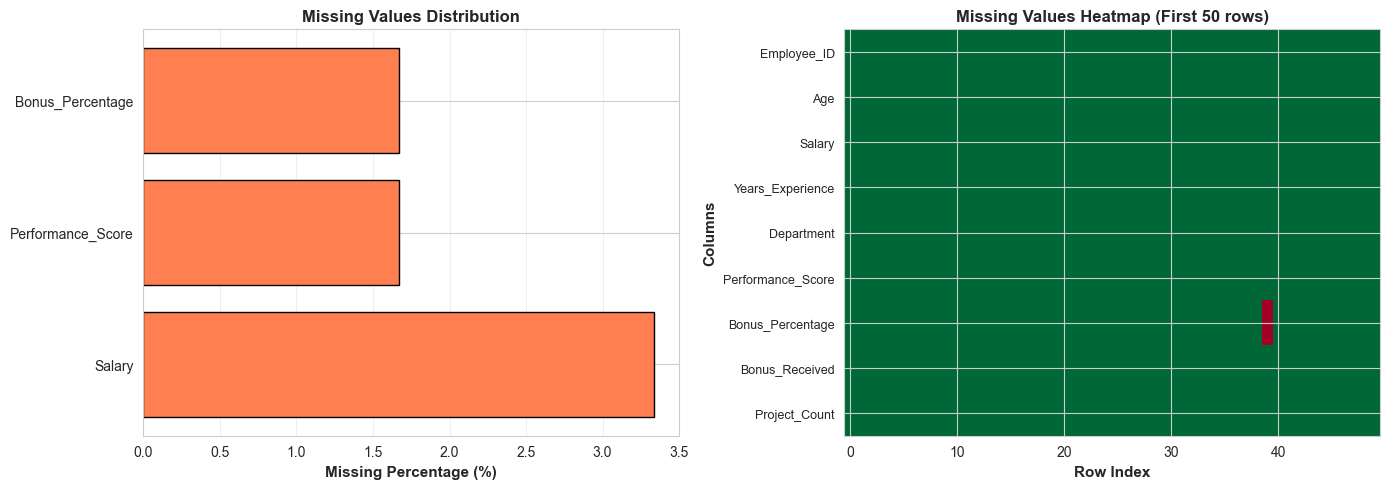

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart of missing percentages
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

axes[0].barh(missing_pct.index, missing_pct.values, color='coral', edgecolor='black')
axes[0].set_xlabel('Missing Percentage (%)', fontsize=11, fontweight='bold')
axes[0].set_title('Missing Values Distribution', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Heatmap showing where missing values are located
# Create boolean DataFrame: True where data is missing
missing_heatmap = df.isnull()

# Display only first 50 rows for clarity (all columns)
axes[1].imshow(missing_heatmap.iloc[:50].T, cmap='RdYlGn_r', aspect='auto')
axes[1].set_xlabel('Row Index', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Columns', fontsize=11, fontweight='bold')
axes[1].set_title('Missing Values Heatmap (First 50 rows)', fontsize=12, fontweight='bold')
# Set column labels to show which columns have missing values
axes[1].set_yticks(range(len(df.columns)))
axes[1].set_yticklabels(df.columns, fontsize=9)

plt.tight_layout()
plt.show()

## 5] Handeling missing values

1. We need to decide what to do with missing values.
2. Options: delete rows, fill with mean/median, fill with mode, or use algorithms.
3. Different strategies for different data types


In [14]:
# select_dtypes(include=[np.number]) selects only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# select_dtypes(include=['object']) selects text/categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric Columns: {numeric_cols}')
print(f'Categorical Columns: {categorical_cols}')


Numeric Columns: ['Employee_ID', 'Age', 'Salary', 'Years_Experience', 'Performance_Score', 'Bonus_Percentage', 'Bonus_Received', 'Project_Count']
Categorical Columns: ['Department']


In [15]:
print('\n--- Strategy 1: Fill Numeric Columns with Median ---')

for col in numeric_cols:
    # Check if this column has missing values
    if df[col].isnull().sum() > 0:
        # Calculate median (middle value)
        median_val = df[col].median()
        
        # Replace all NaN with median value
        df[col].fillna(median_val, inplace=True)
        
        print(f'✓ {col}: Filled missing values with median {median_val:.2f}')



--- Strategy 1: Fill Numeric Columns with Median ---
✓ Salary: Filled missing values with median 95839.50
✓ Performance_Score: Filled missing values with median 76.13
✓ Bonus_Percentage: Filled missing values with median 10.54


In [17]:
print('\n--- Strategy 2: Fill Categorical Columns with Mode ---')

for col in categorical_cols:
    # Check if this column has missing values
    if df[col].isnull().sum() > 0:
        # Calculate mode (most frequent value)
        mode_val = df[col].mode()[0]
        
        # Replace all NaN with mode value
        df[col].fillna(mode_val, inplace=True)
        
        print(f'✓ {col}: Filled missing values with mode "{mode_val}"')


--- Strategy 2: Fill Categorical Columns with Mode ---


In [18]:
print('\n--- After Handling ---')
total_missing = df.isnull().sum().sum()
print(f'Total Missing Values: {total_missing}')
if total_missing == 0:
    print('✓ All missing values handled successfully!')


--- After Handling ---
Total Missing Values: 0
✓ All missing values handled successfully!


## 6] Duplicate Detection and Removal

In [19]:
total_duplicates = df.duplicated().sum()
print(f'Total Completely Duplicate Rows: {total_duplicates}')

Total Completely Duplicate Rows: 0


In [20]:
dup_by_id = df.duplicated(subset=['Employee_ID']).sum()
print(f'Duplicate Employee IDs: {dup_by_id}')

Duplicate Employee IDs: 0


In [21]:
df = df.drop_duplicates(subset=['Employee_ID'], keep='first')

print(f'\n✓ Dataset shape after removing duplicates: {df.shape}')
print(f'Total Rows Removed: {n_samples - len(df)}')


✓ Dataset shape after removing duplicates: (300, 9)
Total Rows Removed: 0


## 7] Outlier Detection and Analysis

1. **IQR METHOD (Interquartile Range)**

In [22]:
def detect_outliers_iqr(data, column):
    # Q1 is 25th percentile (25% of data below this)
    Q1 = data[column].quantile(0.25)
    
    # Q3 is 75th percentile (75% of data below this)
    Q3 = data[column].quantile(0.75)
    
    # IQR is the spread of middle 50% of data
    IQR = Q3 - Q1
    
    # Calculate bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Return boolean array: True where outliers exist
    return (data[column] < lower_bound) | (data[column] > upper_bound), lower_bound, upper_bound

2. **Z-SCORE METHOD**

In [23]:
def detect_outliers_zscore(data, column, threshold=3):
    # stats.zscore() calculates z-scores
    # abs() takes absolute value (distance from mean)
    z_scores = np.abs(stats.zscore(data[column]))
    
    # Return boolean: True where z-score exceeds threshold
    return z_scores > threshold


In [24]:
outlier_columns = ['Age', 'Salary', 'Performance_Score', 'Years_Experience']

In [26]:
#print('\n--- IQR Method ---')
for col in outlier_columns:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    outlier_count = outliers.sum()  # Count how many outliers
    if outlier_count > 0:
        print(f'{col}: {outlier_count} outliers (Bounds: {lower:.2f} - {upper:.2f})')

In [27]:
#print('\n--- Z-Score Method (threshold=3) ---')
for col in outlier_columns:
    outliers = detect_outliers_zscore(df, col, threshold=3)
    outlier_count = outliers.sum()
    if outlier_count > 0:
        print(f'{col}: {outlier_count} outliers')

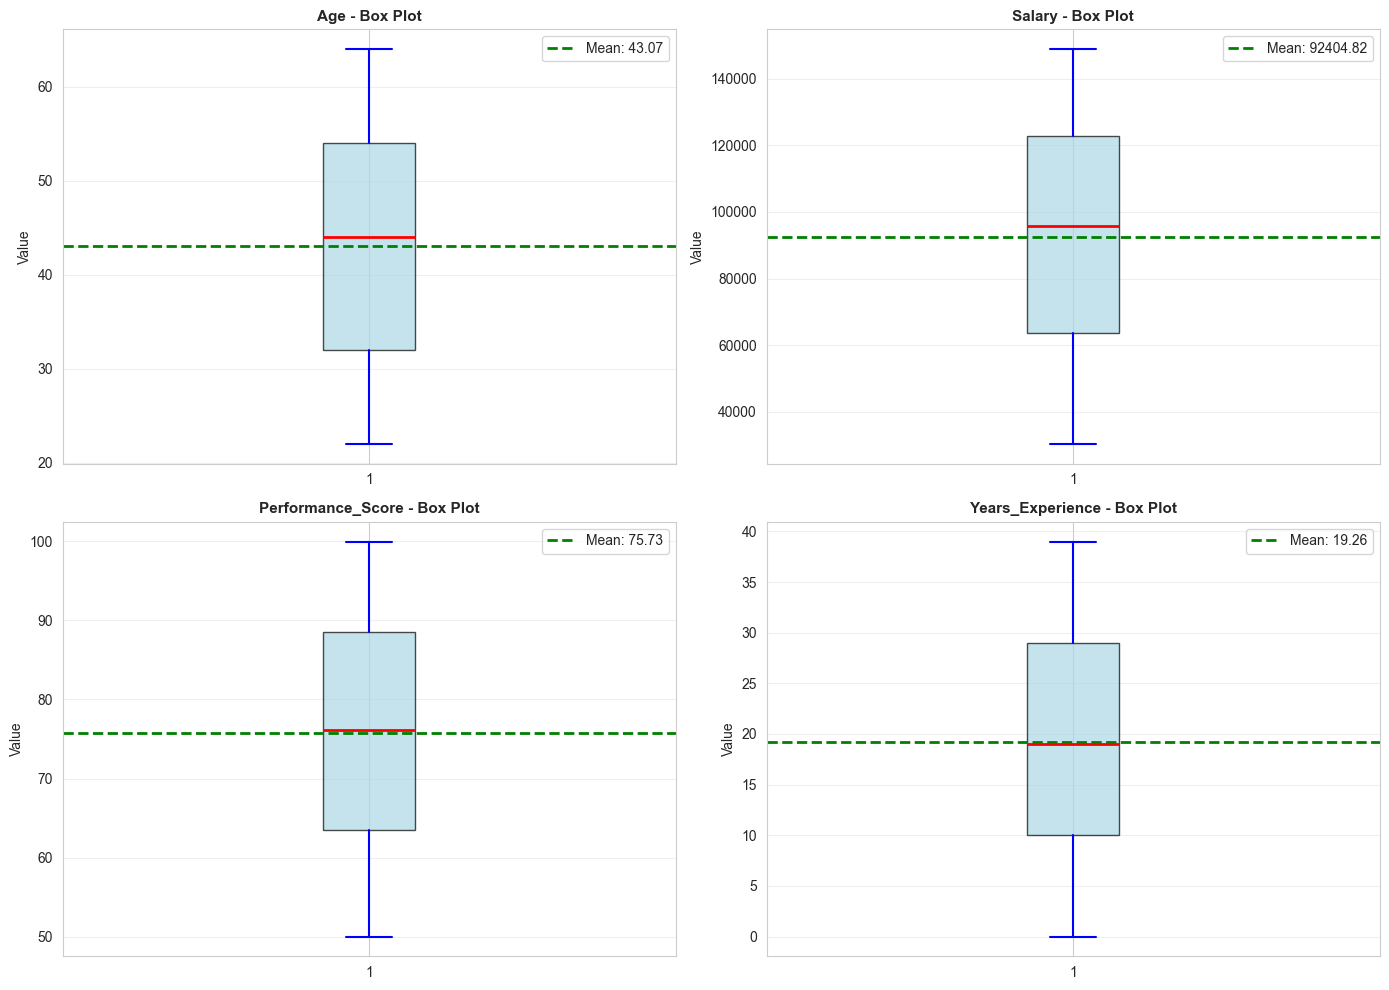


✓ Outliers detected but kept for analysis (not removed)


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()  # Convert 2x2 grid to 1D array for easier indexing

for idx, col in enumerate(outlier_columns):
    # Create box plot
    # patch_artist=True allows us to color the box
    axes[idx].boxplot(df[col], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', alpha=0.7),      # Box color
                     medianprops=dict(color='red', linewidth=2),            # Median line color
                     whiskerprops=dict(color='blue', linewidth=1.5),        # Whisker color
                     capprops=dict(color='blue', linewidth=1.5))            # Cap color
    
    axes[idx].set_title(f'{col} - Box Plot', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Value', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add horizontal line for mean
    mean_val = df[col].mean()
    axes[idx].axhline(mean_val, color='green', linestyle='--', linewidth=2, 
                     label=f'Mean: {mean_val:.2f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

print('\n✓ Outliers detected but kept for analysis (not removed)')

## 8] Data Type Conversion and Optimization

In [29]:
print(df.dtypes)
memory_before = df.memory_usage(deep=True).sum() / 1024
print(f'Memory Usage: {memory_before:.2f} KB')

Employee_ID            int64
Age                    int32
Salary               float64
Years_Experience       int32
Department            object
Performance_Score    float64
Bonus_Percentage     float64
Bonus_Received         int64
Project_Count          int32
dtype: object
Memory Usage: 31.18 KB


In [30]:
# int64 → int16: Age fits in smaller range (22-65), save memory
df['Age'] = df['Age'].astype('int16')

# int64 → int32: Salary needs more space but not int64
df['Salary'] = df['Salary'].astype('int32')

# int64 → int8: Years experience is small number (0-40)
df['Years_Experience'] = df['Years_Experience'].astype('int8')

# int64 → int8: Project count is small (0-15)
df['Project_Count'] = df['Project_Count'].astype('int8')

# 0/1 values → category: Saves space for repeated values
df['Bonus_Received'] = df['Bonus_Received'].astype('category')

# Text with limited options → category: More efficient than object
df['Department'] = df['Department'].astype('category')

In [31]:
print('\n--- After Optimization ---')
print(df.dtypes)
memory_after = df.memory_usage(deep=True).sum() / 1024
memory_saved = memory_before - memory_after
print(f'Memory Usage: {memory_after:.2f} KB')
print(f'Memory Saved: {memory_saved:.2f} KB ({(memory_saved/memory_before*100):.1f}%)')
print('✓ Data types optimized successfully!')


--- After Optimization ---
Employee_ID             int64
Age                     int16
Salary                  int32
Years_Experience         int8
Department           category
Performance_Score     float64
Bonus_Percentage      float64
Bonus_Received       category
Project_Count            int8
dtype: object
Memory Usage: 10.64 KB
Memory Saved: 20.54 KB (65.9%)
✓ Data types optimized successfully!


## 9] Statistical Summary and Distribution

**NUMERICAL STATISTICS**

In [32]:
# describe() calculates: count, mean, std, min, percentiles, max
numerical_stats = df.describe().round(2)
print('\nNumerical Columns Statistics:')
print(numerical_stats)


Numerical Columns Statistics:
       Employee_ID     Age     Salary  Years_Experience  Performance_Score  \
count       300.00  300.00     300.00            300.00             300.00   
mean        150.50   43.07   92404.80             19.26              75.73   
std          86.75   12.51   34143.32             11.30              14.80   
min           1.00   22.00   30301.00              0.00              50.01   
25%          75.75   32.00   63745.00             10.00              63.45   
50%         150.50   44.00   95839.00             19.00              76.13   
75%         225.25   54.00  122809.00             29.00              88.55   
max         300.00   64.00  148937.00             39.00              99.97   

       Bonus_Percentage  Project_Count  
count            300.00         300.00  
mean              10.13           6.59  
std                5.59           4.39  
min                0.02           0.00  
25%                5.10           3.00  
50%               10

**ADVANCED STATISTICAL MEASURES**

In [33]:
# These describe shape and spread of distribution

print('\n--- Additional Statistical Measures ---')
for col in outlier_columns:
    print(f'\n{col}:')
    
    # Skewness: -1=left skew, 0=symmetric, +1=right skew
    print(f'  Skewness: {skew(df[col]):.3f}')
    
    # Kurtosis: measures how peaked/flat distribution is
    print(f'  Kurtosis: {kurtosis(df[col]):.3f}')
    
    # Coefficient of Variation: standard deviation / mean (in %)
    # Measures relative variability
    cv = (df[col].std() / df[col].mean() * 100)
    print(f'  CV (Coefficient of Variation): {cv:.2f}%')


--- Additional Statistical Measures ---

Age:
  Skewness: -0.107
  Kurtosis: -1.220
  CV (Coefficient of Variation): 29.03%

Salary:
  Skewness: -0.156
  Kurtosis: -1.152
  CV (Coefficient of Variation): 36.95%

Performance_Score:
  Skewness: -0.127
  Kurtosis: -1.157
  CV (Coefficient of Variation): 19.54%

Years_Experience:
  Skewness: -0.003
  Kurtosis: -1.151
  CV (Coefficient of Variation): 58.71%


**CATEGORICAL SUMMARY**

In [34]:
print('\n--- Categorical Columns Summary ---')

# value_counts() shows frequency of each category
print(f'\nDepartment Distribution:')
print(df['Department'].value_counts())

print(f'\nBonus Received Distribution:')
print(df['Bonus_Received'].value_counts())


--- Categorical Columns Summary ---

Department Distribution:
Department
Sales        68
HR           64
Marketing    58
Finance      57
IT           53
Name: count, dtype: int64

Bonus Received Distribution:
Bonus_Received
1    152
0    148
Name: count, dtype: int64


## 10] Univariate Analysis - Numerical Variables

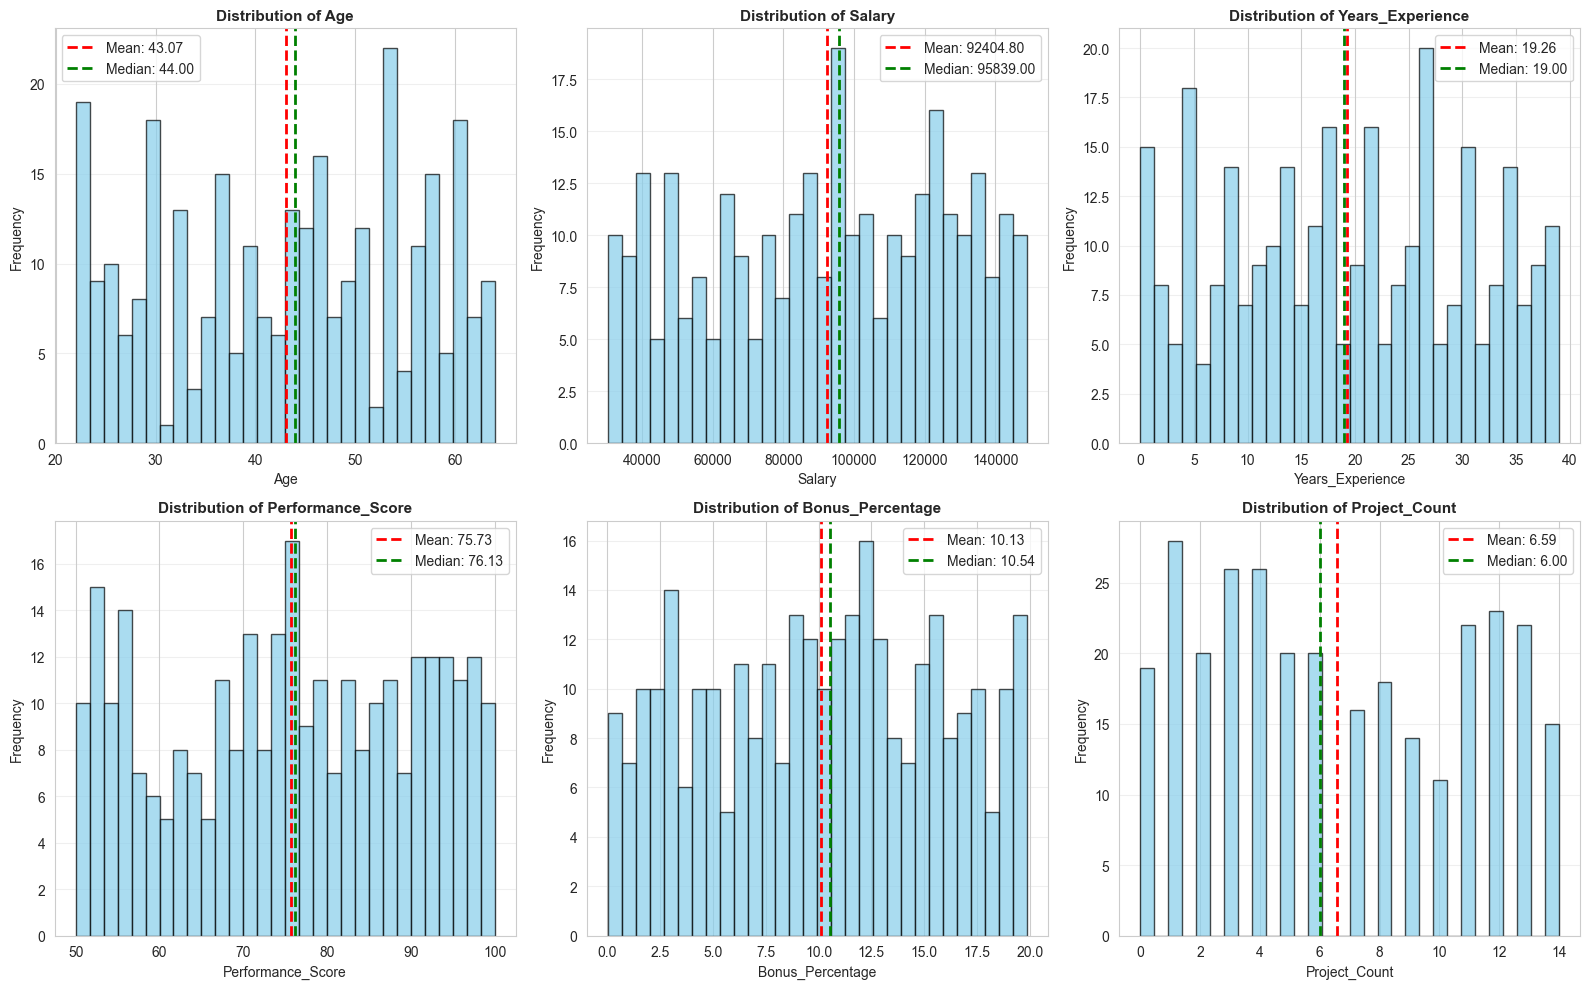

✓ Univariate analysis for numerical variables completed


In [36]:
# Create 6 subplots in 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()  # Flatten to 1D for easier indexing

# List of numerical features to analyze
numerical_features = ['Age', 'Salary', 'Years_Experience', 'Performance_Score', 'Bonus_Percentage', 'Project_Count']

# Loop through each numerical feature
for idx, col in enumerate(numerical_features):
    # Create histogram: shows frequency distribution
    # bins=30 means divide data into 30 bins
    # color='skyblue' sets bar color
    # alpha=0.7 sets transparency (0=invisible, 1=opaque)
    axes[idx].hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Add vertical line at mean
    mean_val = df[col].mean()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                     label=f'Mean: {mean_val:.2f}')
    
    # Add vertical line at median
    median_val = df[col].median()
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, 
                     label=f'Median: {median_val:.2f}')
    
    # Labels and title
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].legend()  # Show the legend
    axes[idx].grid(axis='y', alpha=0.3)  # Add gridlines

plt.tight_layout()
plt.show()
print('✓ Univariate analysis for numerical variables completed')

## 11] Univariate Analysis - Categorical Variables


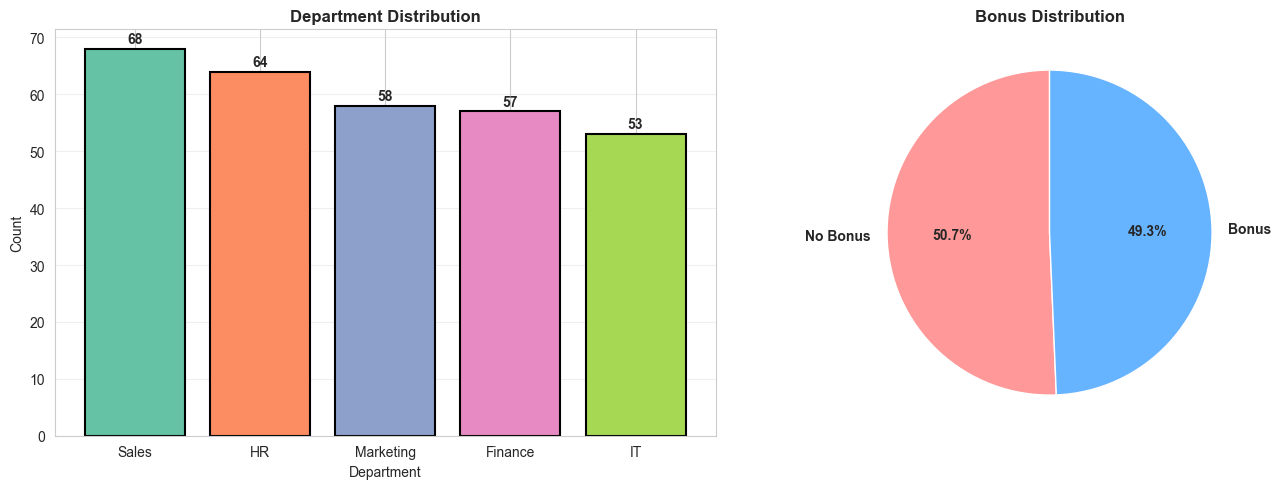

✓ Univariate analysis for categorical variables completed


In [37]:
# Create 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ============================================
# PLOT 1: DEPARTMENT DISTRIBUTION (BAR CHART)
# ============================================
# value_counts() returns frequency of each department
dept_counts = df['Department'].value_counts()

# sns.color_palette creates color scheme with different colors
colors1 = sns.color_palette('Set2', len(dept_counts))

# Create bar chart
# edgecolor adds border around bars
axes[0].bar(dept_counts.index, dept_counts.values, color=colors1, 
           edgecolor='black', linewidth=1.5)
axes[0].set_title('Department Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=10)
axes[0].set_xlabel('Department', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for i, v in enumerate(dept_counts.values):
    # Place text at position (i, v)
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# ============================================
# PLOT 2: BONUS DISTRIBUTION (PIE CHART)
# ============================================
# value_counts() for binary variable shows count of 0s and 1s
bonus_counts = df['Bonus_Received'].value_counts()

# Define pie chart colors: red for no, blue for yes
colors2 = ['#ff9999', '#66b3ff']

# Create pie chart
# autopct='%1.1f%%' shows percentages on pie slices
# startangle=90 rotates chart 90 degrees
axes[1].pie(bonus_counts.values, labels=['No Bonus', 'Bonus'], 
           autopct='%1.1f%%', colors=colors2, startangle=90, 
           textprops={'fontsize': 10, 'fontweight': 'bold'})
axes[1].set_title('Bonus Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print('✓ Univariate analysis for categorical variables completed')

## 12] Bivariate Analysis - Correlation

In [38]:
# SELECT ONLY NUMERIC COLUMNS
# ============================================
# Correlation is meaningless for categorical data
numeric_df = df.select_dtypes(include=[np.number])

# ============================================
# CALCULATE CORRELATION MATRIX
# ============================================
# corr() calculates Pearson correlation coefficient
# Values range from -1 to +1:
# -1 = perfect negative correlation (one increases, other decreases)
#  0 = no correlation
# +1 = perfect positive correlation (both increase together)
correlation_matrix = numeric_df.corr().round(3)

## VISUALIZE CORRELATION WITH HEATMAP

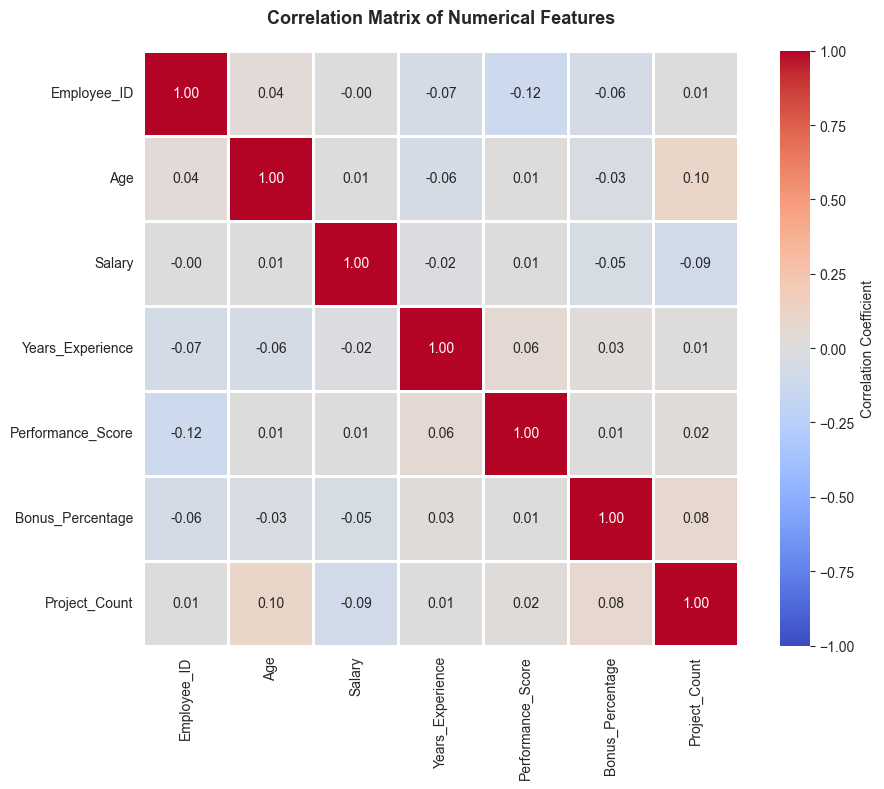

In [39]:
# Heatmap: colors show correlation strength
# Red = positive, Blue = negative, White = no correlation

plt.figure(figsize=(10, 8))

# Create heatmap
# annot=True shows correlation values in cells
# cmap='coolwarm' sets color scheme (cool=blue, warm=red)
# center=0 makes 0 white (neutral)
# fmt='.2f' formats numbers to 2 decimal places
# square=True makes cells square
# linewidths=1 adds borders between cells
# vmin=-1, vmax=1 sets color scale from -1 to +1
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, cbar_kws={'label': 'Correlation Coefficient'},
            vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [42]:
print('\n--- Strong Correlations (|r| > 0.5) ---')

# Loop through upper triangle of correlation matrix
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        # Get correlation value
        corr_val = correlation_matrix.iloc[i, j]
        
        # Only print if absolute value > 0.5
        if abs(corr_val) > 0.5:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            print(f'{col1} ↔ {col2}: {corr_val:.3f}')


--- Strong Correlations (|r| > 0.5) ---


## 13] Bivariate Analysis - Scatter Plots


**VISUALIZE RELATIONSHIPS WITH SCATTER PLOTS**

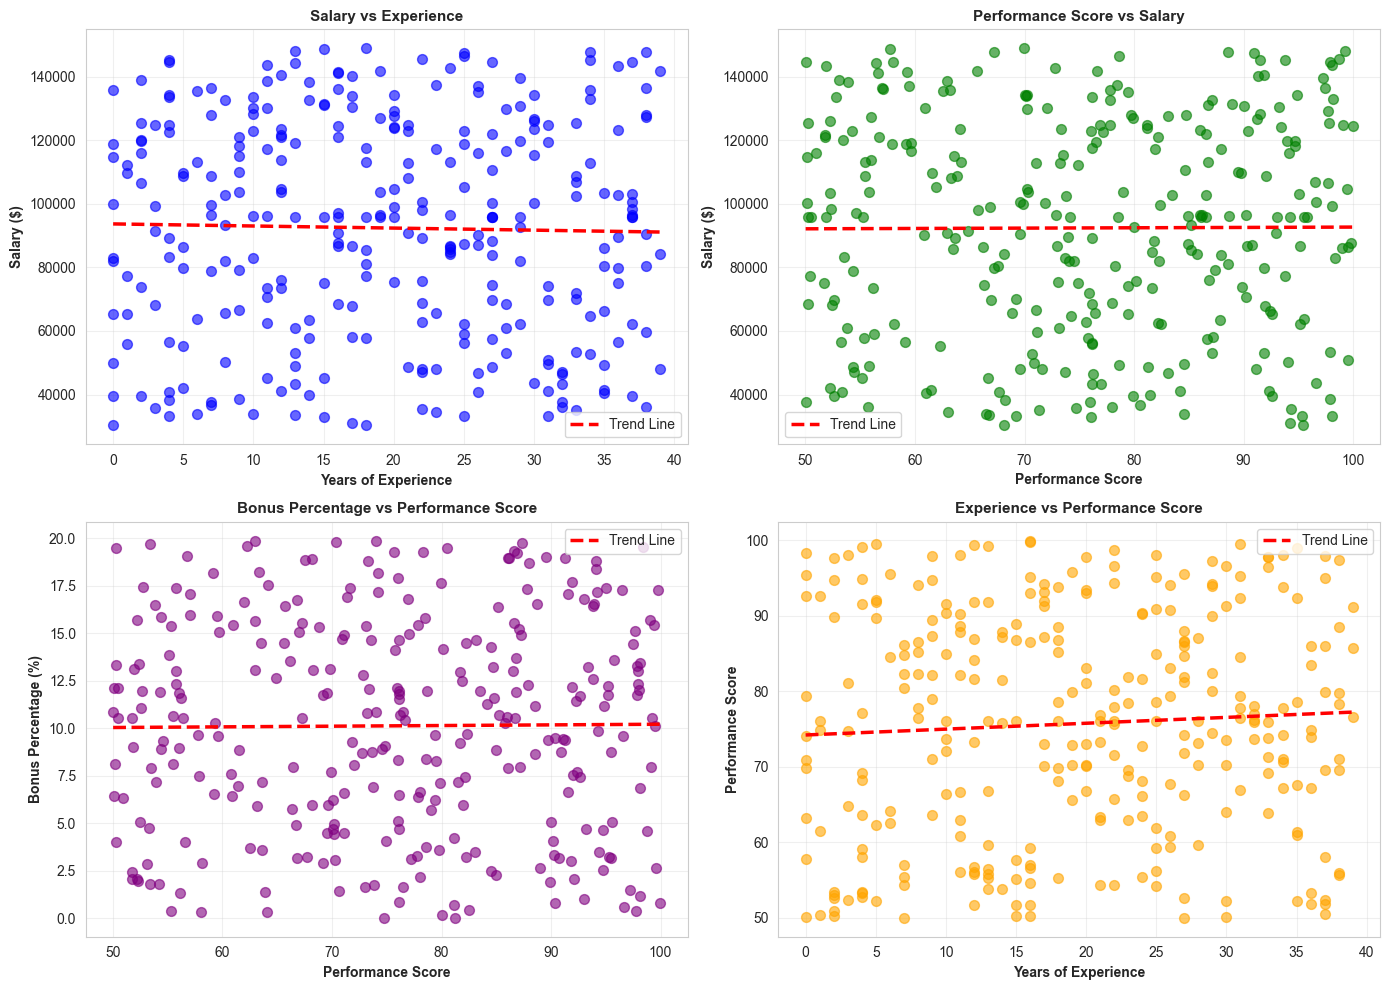

✓ Bivariate analysis completed successfully


In [43]:
# Create 4 subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ============================================
# PLOT 1: SALARY VS EXPERIENCE
# ============================================
# scatter() creates scatter plot
# alpha=0.6 makes points semi-transparent (helps see overlapping points)
# s=50 sets point size
axes[0, 0].scatter(df['Years_Experience'], df['Salary'], alpha=0.6, color='blue', s=50)

# Add trend line (polynomial fit of degree 1 = straight line)
# polyfit() fits polynomial: degree 1 = linear
z1 = np.polyfit(df['Years_Experience'], df['Salary'], 1)

# poly1d() creates polynomial from coefficients
p1 = np.poly1d(z1)

# Sort experience values for smooth line
x_sorted = df['Years_Experience'].sort_values()
axes[0, 0].plot(x_sorted, p1(x_sorted), "r--", linewidth=2.5, label='Trend Line')

axes[0, 0].set_xlabel('Years of Experience', fontsize=10, fontweight='bold')
axes[0, 0].set_ylabel('Salary ($)', fontsize=10, fontweight='bold')
axes[0, 0].set_title('Salary vs Experience', fontsize=11, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# ============================================
# PLOT 2: PERFORMANCE SCORE VS SALARY
# ============================================
axes[0, 1].scatter(df['Performance_Score'], df['Salary'], alpha=0.6, color='green', s=50)

# Add trend line
z2 = np.polyfit(df['Performance_Score'], df['Salary'], 1)
p2 = np.poly1d(z2)
x_sorted2 = df['Performance_Score'].sort_values()
axes[0, 1].plot(x_sorted2, p2(x_sorted2), "r--", linewidth=2.5, label='Trend Line')
axes[0, 1].set_xlabel('Performance Score', fontsize=10, fontweight='bold')
axes[0, 1].set_ylabel('Salary ($)', fontsize=10, fontweight='bold')
axes[0, 1].set_title('Performance Score vs Salary', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
# ============================================
# PLOT 3: BONUS PERCENTAGE VS PERFORMANCE SCORE
# ============================================
axes[1, 0].scatter(df['Performance_Score'], df['Bonus_Percentage'], alpha=0.6, color='purple', s=50)
# Add trend line
z3 = np.polyfit(df['Performance_Score'], df['Bonus_Percentage'],1)
p3 = np.poly1d(z3)
x_sorted3 = df['Performance_Score'].sort_values()
axes[1, 0].plot(x_sorted3, p3(x_sorted3), "r--", linewidth=2.5, label='Trend Line')
axes[1, 0].set_xlabel('Performance Score', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Bonus Percentage (%)', fontsize=10, fontweight='bold')
axes[1, 0].set_title('Bonus Percentage vs Performance Score', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
# ============================================
# PLOT 4: EXPERIENCE VS PERFORMANCE SCORE
# ============================================
axes[1, 1].scatter(df['Years_Experience'], df['Performance_Score'], alpha=0.6, color='orange', s=50)
# Add trend line
z4 = np.polyfit(df['Years_Experience'], df['Performance_Score'], 1)
p4 = np.poly1d(z4)
x_sorted4 = df['Years_Experience'].sort_values()
axes[1, 1].plot(x_sorted4, p4(x_sorted4), "r--", linewidth=2.5, label='Trend Line')
axes[1, 1].set_xlabel('Years of Experience', fontsize=10, fontweight='bold')
axes[1, 1].set_ylabel('Performance Score', fontsize=10, fontweight='bold')
axes[1, 1].set_title('Experience vs Performance Score', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('✓ Bivariate analysis completed successfully')

## 14] Categorical Analysis with Statistical Comparisons

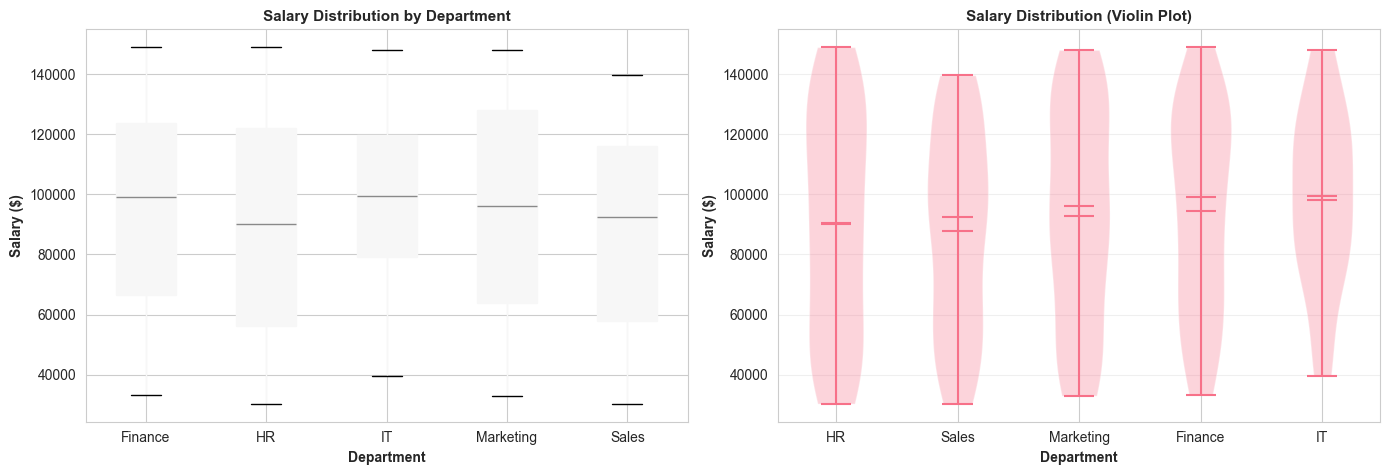

In [44]:
# Create 2 plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ============================================
# PLOT 1: BOX PLOT
# ============================================
# Box plot shows distribution summary for each group
# Line in box = median
# Box = middle 50% of data
# Whiskers = range (excluding outliers)
# Dots = outliers

# boxplot() with 'by' parameter groups by a column
df.boxplot(column='Salary', by='Department', ax=axes[0], patch_artist=True)
axes[0].set_title('Salary Distribution by Department', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Department', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Salary ($)', fontsize=10, fontweight='bold')
axes[0].get_figure().suptitle('')  # Remove automatic title

# ============================================
# PLOT 2: VIOLIN PLOT
# ============================================
# Violin plot shows full distribution (like sideways histogram)
# Width = frequency of values at that point

# violinplot() creates violin plot
# positions: x-axis positions for each group
# showmeans=True adds mean as dot
# showmedians=True adds median as line
parts = axes[1].violinplot([df[df['Department'] == dept]['Salary'].values 
                             for dept in df['Department'].unique()],
                            positions=range(len(df['Department'].unique())),
                            showmeans=True, showmedians=True)

# Set x-axis labels
axes[1].set_xticks(range(len(df['Department'].unique())))
axes[1].set_xticklabels(df['Department'].unique())
axes[1].set_title('Salary Distribution (Violin Plot)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Salary ($)', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Department', fontsize=10, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## STATISTICAL SUMMARY BY CATEGORY

In [45]:
dept_salary_stats = df.groupby('Department')['Salary'].agg([
    'count',      # Number of employees per department
    'mean',       # Average salary
    'median',     # Middle salary
    'std',        # Standard deviation (spread)
    'min',        # Minimum salary
    'max'         # Maximum salary
]).round(2)

print(dept_salary_stats)

            count      mean   median       std    min     max
Department                                                   
Finance        57  94341.51  99042.0  33726.72  33343  148834
HR             64  90424.45  89983.5  37316.67  30412  148937
IT             53  98179.57  99449.0  29475.49  39435  147858
Marketing      58  92855.52  96212.5  36017.78  33051  148015
Sales          68  87759.88  92470.0  33301.19  30301  139616


## 15] Statistical Hypothesis Testing

**TEST 1: T-TEST**

In [46]:
 # Compares means of TWO groups
# Null hypothesis (H0): means are equal
# If p-value < 0.05: means are significantly different

print('\n--- T-Test: Salary by Bonus Status ---')

# Separate salary data by bonus status
# Bonus_Received == 1 means received bonus
bonus_yes = df[df['Bonus_Received'] == 1]['Salary']
# Bonus_Received == 0 means no bonus
bonus_no = df[df['Bonus_Received'] == 0]['Salary']

# ttest_ind() does independent samples t-test
t_stat, p_value = stats.ttest_ind(bonus_yes, bonus_no)

print(f'Bonus Recipients Mean Salary: ${bonus_yes.mean():.2f}')
print(f'Non-Recipients Mean Salary: ${bonus_no.mean():.2f}')
print(f'Difference: ${abs(bonus_yes.mean() - bonus_no.mean()):.2f}')
print(f'T-statistic: {t_stat:.4f}')  # Larger absolute value = bigger difference
print(f'P-value: {p_value:.6f}')     # Smaller p-value = more significant
print(f'Result: {"Statistically Significant (p < 0.05)" if p_value < 0.05 else "Not Significant"}')


--- T-Test: Salary by Bonus Status ---
Bonus Recipients Mean Salary: $88773.55
Non-Recipients Mean Salary: $96134.20
Difference: $7360.65
T-statistic: -1.8747
P-value: 0.061819
Result: Not Significant


**TEST 2: ANOVA (Analysis of Variance)**

In [47]:
# Compares means of THREE OR MORE groups
# Null hypothesis: all means are equal

print('\n--- ANOVA Test: Salary Across Departments ---')

# Create list of salary values for each department
# For each unique department, extract salary values
dept_groups = [group['Salary'].values for name, group in df.groupby('Department')]

# f_oneway() does ANOVA test
f_stat, p_value_anova = stats.f_oneway(*dept_groups)

print(f'F-statistic: {f_stat:.4f}')  # Larger F = bigger differences between groups
print(f'P-value: {p_value_anova:.6f}')
print(f'Result: {"Statistically Significant (p < 0.05)" if p_value_anova < 0.05 else "Not Significant"}')



--- ANOVA Test: Salary Across Departments ---
F-statistic: 0.7937
P-value: 0.530057
Result: Not Significant


**TEST 3: NORMALITY TEST (Shapiro-Wilk)**

In [48]:
print('\n--- Normality Test (Shapiro-Wilk) ---')

# shapiro() tests normality
shapiro_stat, shapiro_p = shapiro(df['Salary'])

print(f'Shapiro-Wilk Statistic: {shapiro_stat:.4f}')
print(f'P-value: {shapiro_p:.6f}')
print(f'Distribution: {"Normal" if shapiro_p > 0.05 else "Not Normal"}')


--- Normality Test (Shapiro-Wilk) ---
Shapiro-Wilk Statistic: 0.9532
P-value: 0.000000
Distribution: Not Normal


**TEST 4: CHI-SQUARE TEST**

In [49]:
print('\n--- Chi-Square Test: Department vs Bonus Status ---')

# crosstab() creates contingency table (frequency table)
# Shows count of observations for each combination
contingency_table = pd.crosstab(df['Department'], df['Bonus_Received'])

# chi2_contingency() performs chi-square test
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency_table)

print(f'Chi-Square Statistic: {chi2:.4f}')
print(f'P-value: {p_chi:.6f}')
print(f'Degrees of Freedom: {dof}')
print(f'Result: {"Significant Association (p < 0.05)" if p_chi < 0.05 else "No Significant Association"}')
print(f'\nContingency Table:\n{contingency_table}')


--- Chi-Square Test: Department vs Bonus Status ---
Chi-Square Statistic: 4.5609
P-value: 0.335393
Degrees of Freedom: 4
Result: No Significant Association

Contingency Table:
Bonus_Received   0   1
Department            
Finance         27  30
HR              38  26
IT              27  26
Marketing       28  30
Sales           28  40


## 16] Feature Engineering

In [50]:
# ============================================
# FEATURE 1: SALARY PER YEAR OF EXPERIENCE
# ============================================
# Divides salary by experience: shows salary growth efficiency
# Add 1 to avoid division by zero for people with 0 experience
df['Salary_per_Experience'] = df['Salary'] / (df['Years_Experience'] + 1)

# ============================================
# FEATURE 2: AGE GROUPS
# ============================================
# Converts continuous age into categorical age groups
# pd.cut() divides data into bins
# bins=[0, 30, 40, 50, 100] creates: 0-30, 30-40, 40-50, 50-100
df['Age_Group'] = pd.cut(df['Age'], 
                          bins=[0, 30, 40, 50, 100], 
                          labels=['18-30', '30-40', '40-50', '50+'])

# ============================================
# FEATURE 3: EXPERIENCE CATEGORIES
# ============================================
# Converts continuous experience into levels
df['Experience_Category'] = pd.cut(df['Years_Experience'], 
                                   bins=[-1, 2, 5, 10, 40],
                                   labels=['Entry', 'Junior', 'Mid', 'Senior'])

# ============================================
# FEATURE 4: HIGH PERFORMER FLAG
# ============================================
# Binary flag: 1 if in top 25% performers, 0 otherwise
# quantile(0.75) returns 75th percentile (top 25% threshold)
df['High_Performer'] = (df['Performance_Score'] >= df['Performance_Score'].quantile(0.75)).astype(int)

# ============================================
# FEATURE 5: HIGH SALARY FLAG
# ============================================
# Binary flag: 1 if in top 25% earners, 0 otherwise
df['High_Salary'] = (df['Salary'] >= df['Salary'].quantile(0.75)).astype(int)

# ============================================
# FEATURE 6: SALARY-PERFORMANCE INDEX
# ============================================
# Combines salary and performance into single metric (0-1 scale)
# (Salary / Max_Salary) * (Performance / 100)
df['Salary_Performance_Index'] = (df['Salary'] / df['Salary'].max()) * (df['Performance_Score'] / 100)


In [51]:
print('\n--- New Features Created ---')
print(f'1. Salary_per_Experience: Salary divided by experience')
print(f'2. Age_Group: Categorical age ranges')
print(f'3. Experience_Category: Experience levels (Entry/Junior/Mid/Senior)')
print(f'4. High_Performer: Top 25% performers (binary)')
print(f'5. High_Salary: Top 25% earners (binary)')
print(f'6. Salary_Performance_Index: Combined metric (0-1)')


--- New Features Created ---
1. Salary_per_Experience: Salary divided by experience
2. Age_Group: Categorical age ranges
3. Experience_Category: Experience levels (Entry/Junior/Mid/Senior)
4. High_Performer: Top 25% performers (binary)
5. High_Salary: Top 25% earners (binary)
6. Salary_Performance_Index: Combined metric (0-1)


In [52]:
# ============================================
# DISPLAY NEW FEATURES
# ============================================
print('\n--- Feature Preview ---')
print(df[['Salary', 'Years_Experience', 'Salary_per_Experience', 'Age_Group', 
         'Experience_Category', 'High_Performer', 'High_Salary']].head(10))



--- Feature Preview ---
   Salary  Years_Experience  Salary_per_Experience Age_Group  \
0  127888                38            3279.179487       50+   
1   69790                31            2180.937500     40-50   
2  137455                23            5727.291667     30-40   
3   35600                22            1547.826087       50+   
4  124660                31            3895.625000     18-30   
5  123179                36            3329.162162     40-50   
6   70764                11            5897.000000       50+   
7  104543                12            8041.769231     30-40   
8   75714                22            3291.913043     40-50   
9   86835                24            3473.400000     30-40   

  Experience_Category  High_Performer  High_Salary  
0              Senior               0            1  
1              Senior               0            0  
2              Senior               0            1  
3              Senior               1            0  
4    

In [53]:
# ============================================
# NEW FEATURE DISTRIBUTIONS
# ============================================
print('\n--- Feature Distributions ---')
print(f'\nAge Group Distribution:')
print(df['Age_Group'].value_counts().sort_index())  # sort_index shows in order

print(f'\nExperience Category Distribution:')
print(df['Experience_Category'].value_counts().sort_index())


--- Feature Distributions ---

Age Group Distribution:
Age_Group
18-30    70
30-40    55
40-50    76
50+      99
Name: count, dtype: int64

Experience Category Distribution:
Experience_Category
Entry      23
Junior     23
Mid        33
Senior    221
Name: count, dtype: int64


## 17] Summary and Comprehensive Insights


**COMPREHENSIVE DATA ANALYSIS SUMMARY**

In [56]:
# ============================================
# 1. DATASET OVERVIEW
# ============================================
print(f'\n1. DATASET OVERVIEW')
print(f'   - Total Records: {len(df):,}')
print(f'   - Total Features: {len(df.columns)}')
print(f'   - Numeric Columns: {len(numeric_df.columns)}')
print(f'   - Categorical Columns: {len(categorical_cols)}')
memory_kb = df.memory_usage(deep=True).sum() / 1024
print(f'   - Memory Usage: {memory_kb:.2f} KB')

# ============================================
# 2. SALARY INSIGHTS
# ============================================
print(f'\n2. SALARY INSIGHTS')
print(f'   - Average Salary: ${df["Salary"].mean():,.2f}')
print(f'   - Median Salary: ${df["Salary"].median():,.2f}')
print(f'   - Standard Deviation: ${df["Salary"].std():,.2f}')
print(f'   - Minimum Salary: ${df["Salary"].min():,.2f}')
print(f'   - Maximum Salary: ${df["Salary"].max():,.2f}')
print(f'   - Salary Range: ${df["Salary"].max() - df["Salary"].min():,.2f}')

# ============================================
# 3. WORKFORCE COMPOSITION
# ============================================
print(f'\n3. WORKFORCE COMPOSITION')
print(f'   - Average Age: {df["Age"].mean():.1f} years')
print(f'   - Average Experience: {df["Years_Experience"].mean():.1f} years')
print(f'   - Average Performance Score: {df["Performance_Score"].mean():.2f}')
# Count employees with bonus: Bonus_Received == 1
bonus_pct = (df['Bonus_Received'].eq(1).sum() / len(df) * 100)
print(f'   - Employees with Bonus: {bonus_pct:.1f}%')

# ============================================
# 4. DEPARTMENT ANALYSIS
# ============================================
print(f'\n4. DEPARTMENT ANALYSIS')

# Group by department and aggregate salary, count employees
dept_analysis = df.groupby('Department').agg({
    'Salary': ['count', 'mean', 'median'],
    'Performance_Score': 'mean'
}).round(2)
print(dept_analysis)

# ============================================
# 5. PERFORMANCE METRICS
# ============================================
print(f'\n5. PERFORMANCE METRICS')
high_perf_count = df["High_Performer"].sum()
high_perf_pct = (high_perf_count / len(df) * 100)
print(f'   - High Performers: {high_perf_count} ({high_perf_pct:.1f}%)')

high_salary_count = df["High_Salary"].sum()
high_salary_pct = (high_salary_count / len(df) * 100)
print(f'   - High Earners: {high_salary_count} ({high_salary_pct:.1f}%)')

print(f'   - Average Bonus Percentage: {df["Bonus_Percentage"].mean():.2f}%')

# ============================================
# 6. TOP CORRELATIONS WITH SALARY
# ============================================
print(f'\n6. TOP CORRELATIONS WITH SALARY')

# Sort correlations by absolute value, exclude salary itself
correlations = numeric_df.corr()['Salary'].abs().sort_values(ascending=False)[1:4]
for feature, corr in correlations.items():
    print(f'   - {feature}: {corr:.3f}')

print('\n' + '='*70)
print('✓ Analysis completed successfully!')
print('='*70)


1. DATASET OVERVIEW
   - Total Records: 300
   - Total Features: 15
   - Numeric Columns: 7
   - Categorical Columns: 1
   - Memory Usage: 21.36 KB

2. SALARY INSIGHTS
   - Average Salary: $92,404.80
   - Median Salary: $95,839.00
   - Standard Deviation: $34,143.32
   - Minimum Salary: $30,301.00
   - Maximum Salary: $148,937.00
   - Salary Range: $118,636.00

3. WORKFORCE COMPOSITION
   - Average Age: 43.1 years
   - Average Experience: 19.3 years
   - Average Performance Score: 75.73
   - Employees with Bonus: 50.7%

4. DEPARTMENT ANALYSIS
           Salary                    Performance_Score
            count      mean   median              mean
Department                                            
Finance        57  94341.51  99042.0             70.69
HR             64  90424.45  89983.5             73.43
IT             53  98179.57  99449.0             78.70
Marketing      58  92855.52  96212.5             77.40
Sales          68  87759.88  92470.0             78.38

5. PERFOR

## 18] Data Export and Report Generation


In [57]:
# SAVE CLEANED DATASET
# to_csv() exports DataFrame to CSV file (Excel-readable)
# index=False prevents adding row numbers as first column
df.to_csv('cleaned_employee_data.csv', index=False)
print('✓ Cleaned data saved to "cleaned_employee_data.csv"')

✓ Cleaned data saved to "cleaned_employee_data.csv"


In [58]:
# CREATE DATA QUALITY REPORT
# Create summary of data quality metrics

quality_report = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Total Features',
        'Missing Values',
        'Duplicate Rows',
        'Data Quality Score (%)'
    ],
    'Value': [
        len(df),
        len(df.columns),
        df.isnull().sum().sum(),  # Total NaN count
        df.duplicated().sum(),     # Total duplicate rows
        # Quality score = percentage of non-missing values
        round((1 - (df.isnull().sum().sum() / (len(df) * len(df.columns)))) * 100, 2)
    ]
})

print('\n' + '='*70)
print('DATA QUALITY REPORT')
print('='*70)
print(quality_report.to_string(index=False))


DATA QUALITY REPORT
                Metric  Value
         Total Records  300.0
        Total Features   15.0
        Missing Values    0.0
        Duplicate Rows    0.0
Data Quality Score (%)  100.0


In [59]:
# EXPORT SUMMARY STATISTICS
# describe() shows statistical summary
summary_stats = df.describe(include='all').round(2)

# to_csv() exports to file
summary_stats.to_csv('summary_statistics.csv')
print('\n✓ Summary statistics saved to "summary_statistics.csv"')



✓ Summary statistics saved to "summary_statistics.csv"


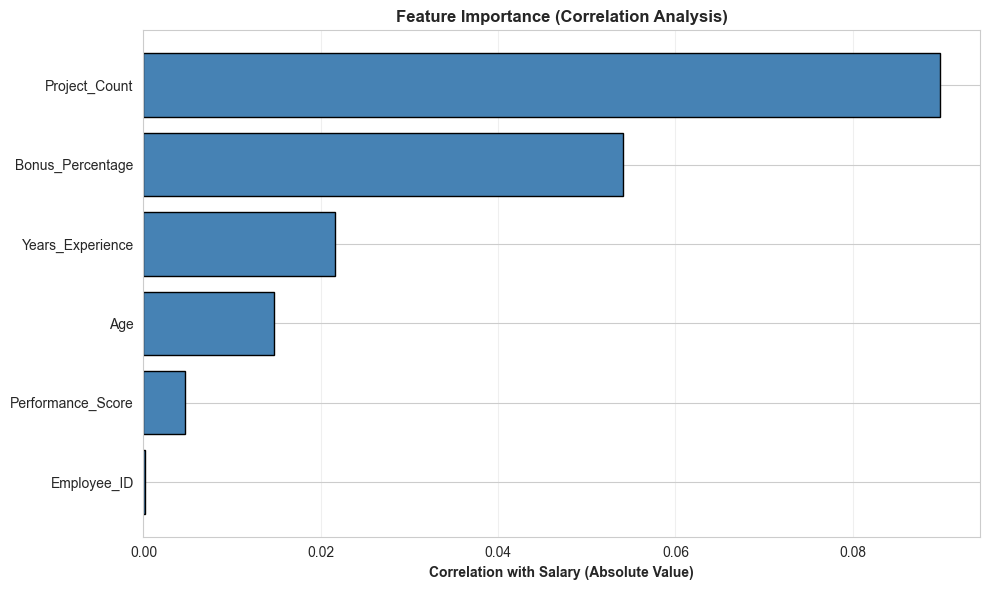


✓ All analysis files generated successfully!


In [60]:
# FEATURE IMPORTANCE VISUALIZATION
# Show which variables are most related to salary

fig, ax = plt.subplots(figsize=(10, 6))

# Get absolute correlation values (ignore direction)
# Sort ascending so smallest is at bottom
feature_importance = numeric_df.corr()['Salary'].abs().sort_values(ascending=True)[:-1]

# Create horizontal bar chart
ax.barh(feature_importance.index, feature_importance.values, 
        color='steelblue', edgecolor='black')
ax.set_xlabel('Correlation with Salary (Absolute Value)', fontweight='bold')
ax.set_title('Feature Importance (Correlation Analysis)', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n✓ All analysis files generated successfully!')